# Baseline logistic regression

Before trying tree models, I want a simple reference using only information from the previous inspection. This gives us a baseline for the later feature and model comparisons. Class weighting handles the imbalance, PR-AUC is the main metric since Non-Pass is rare.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

df = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                  parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
print("rows:", len(df))

rows: 69766


## Check the dataset matches what we expect

If these numbers don't match, something upstream changed and needs investigating before modelling on it.

In [2]:
print("establishments:", df["estId"].nunique())
print("date range:", df["inspectionDate"].min(), "to", df["inspectionDate"].max())
print(df["target"].value_counts())
print("non-pass %:", round(100 * df["target"].mean(), 3))

assert len(df) == 69766
assert df["estId"].nunique() == 16779
assert (df["target"] == 0).sum() == 65543
assert (df["target"] == 1).sum() == 4223
print("matches expected numbers")

establishments: 16779
date range: 2023-11-10 00:00:00 to 2026-09-08 00:00:00
target
0    65543
1     4223
Name: count, dtype: int64
non-pass %: 6.053
matches expected numbers


## Baseline features

Only the immediate-previous-inspection features. No 365-day history, no lat/lon, no identifiers.

In [3]:
FEATURES = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
            "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
assert identifier_cols.isdisjoint(FEATURES)
assert "latitude" not in FEATURES and "longitude" not in FEATURES
assert not any(f.startswith("prior_365d") for f in FEATURES)
FEATURES

['days_since_previous_inspection',
 'prev_non_pass',
 'prev_total_infractions',
 'prev_minor',
 'prev_significant',
 'prev_crucial',
 'n_inspections_seen_so_far']

## Chronological train / validation / test split

Sorted by target inspection date, then split by row count: earliest 70% train, next 15% validation, last 15% test. The same establishment can appear in more than one split if its inspections span the boundary, that's expected for a future-prediction setup.

In [4]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name}: rows={len(part)} establishments={part['estId'].nunique()} "
          f"dates {part['inspectionDate'].min().date()} to {part['inspectionDate'].max().date()} "
          f"non-pass%={round(100*part['target'].mean(),3)}")

assert train["inspectionDate"].max() <= val["inspectionDate"].min()
assert val["inspectionDate"].max() <= test["inspectionDate"].min()

train: rows=48836 establishments=14932 dates 2023-11-10 to 2025-12-22 non-pass%=5.631
val: rows=10465 establishments=9369 dates 2025-12-22 to 2026-05-04 non-pass%=6.574
test: rows=10465 establishments=9155 dates 2026-05-04 to 2026-09-08 non-pass%=7.501


In [5]:
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(name, part["target"].value_counts().to_dict())

train {0: 46086, 1: 2750}
val {0: 9777, 1: 688}
test {0: 9680, 1: 785}


## Fit preprocessing and logistic regression

Median imputation plus standard scaling, fit on the training set only. `class_weight="balanced"` handles the imbalance instead of resampling.

In [6]:
X_train, y_train = train[FEATURES], train["target"]
X_val, y_val = val[FEATURES], val["target"]
X_test, y_test = test[FEATURES], test["target"]

pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

pipe.fit(X_train, y_train)
print("fitted")

fitted


## Validation performance (threshold-free)

In [7]:
val_proba = pipe.predict_proba(X_val)[:, 1]

val_pr_auc = average_precision_score(y_val, val_proba)
val_roc_auc = roc_auc_score(y_val, val_proba)

print("validation PR-AUC:", round(val_pr_auc, 4))
print("validation ROC-AUC:", round(val_roc_auc, 4))
print("validation non-pass prevalence:", round(y_val.mean(), 4))

validation PR-AUC: 0.1167
validation ROC-AUC: 0.6395
validation non-pass prevalence: 0.0657


PR-AUC should be compared against the prevalence, not against 1.0, since prevalence is what a random/no-skill classifier would score on this metric.

## Threshold check on validation only

A small set of reasonable thresholds, picking the one with the best F1. Test labels aren't touched here.

In [8]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
rows = []
for t in thresholds:
    pred = (val_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
    })
thresh_df = pd.DataFrame(rows)
thresh_df

,threshold,precision,recall,f1
0,0.3,0.068579,0.986919,0.128246
1,0.4,0.070082,0.956395,0.130594
2,0.5,0.105105,0.508721,0.174216
3,0.6,0.150519,0.252907,0.188720
4,0.7,0.192118,0.056686,0.087542


In [9]:
best_t = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]
print("chosen threshold (best validation F1):", best_t)

chosen threshold (best validation F1): 0.6


## Final test evaluation, threshold locked

In [10]:
test_proba = pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_t).astype(int)

test_pr_auc = average_precision_score(y_test, test_proba)
test_roc_auc = roc_auc_score(y_test, test_proba)
test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)
test_accuracy = accuracy_score(y_test, test_pred)
cm = confusion_matrix(y_test, test_pred)

print("test PR-AUC:", round(test_pr_auc, 4), " (prevalence:", round(y_test.mean(), 4), ")")
print("test ROC-AUC:", round(test_roc_auc, 4))
print("test precision:", round(test_precision, 4))
print("test recall:", round(test_recall, 4))
print("test f1:", round(test_f1, 4))
print("test accuracy:", round(test_accuracy, 4))
print("confusion matrix (rows=actual, cols=predicted):\n", cm)

test PR-AUC: 0.1327  (prevalence: 0.075 )
test ROC-AUC: 0.6459
test precision: 0.1545
test recall: 0.2318
test f1: 0.1854
test accuracy: 0.8472
confusion matrix (rows=actual, cols=predicted):
 [[8684  996]
 [ 603  182]]


## Majority baseline (always predict Pass)

Just to show what "no useful prediction" looks like on the same test set.

In [11]:
maj_pred = np.zeros(len(y_test), dtype=int)
maj_accuracy = accuracy_score(y_test, maj_pred)
maj_precision = precision_score(y_test, maj_pred, zero_division=0)
maj_recall = recall_score(y_test, maj_pred, zero_division=0)
maj_f1 = f1_score(y_test, maj_pred, zero_division=0)

print("majority baseline accuracy:", round(maj_accuracy, 4))
print("majority baseline precision:", round(maj_precision, 4))
print("majority baseline recall:", round(maj_recall, 4))
print("majority baseline f1:", round(maj_f1, 4))

majority baseline accuracy: 0.925
majority baseline precision: 0.0
majority baseline recall: 0.0
majority baseline f1: 0.0


Majority-class accuracy is high (as expected with a 92.5% Pass rate) but its precision, recall and F1 for the Non-Pass class are all 0, since it never predicts Non-Pass. Accuracy alone would be misleading here.

## PR and ROC curves (test set)

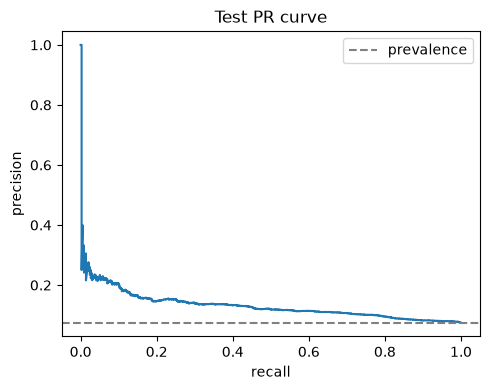

In [12]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)
plt.figure(figsize=(5, 4))
plt.plot(recall_curve, precision_curve)
plt.axhline(y_test.mean(), linestyle="--", color="gray", label="prevalence")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Test PR curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/baseline_pr_curve.png", dpi=100)
plt.show()

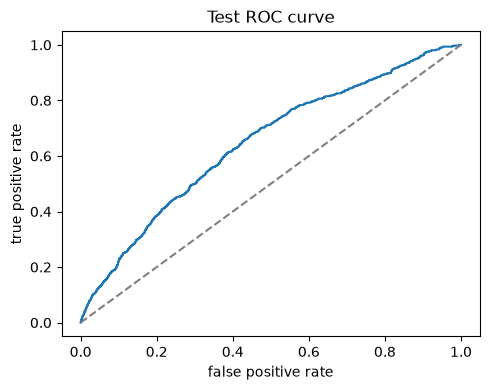

In [13]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Test ROC curve")
plt.tight_layout()
plt.savefig("../outputs/figures/baseline_roc_curve.png", dpi=100)
plt.show()

## Coefficients

Positive means associated with higher predicted Non-Pass odds, negative means lower. These are model coefficients on standardized features, not proof of cause and effect, and not directly a percentage risk change.

In [14]:
coefs = pipe.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": FEATURES, "coefficient": coefs})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
coef_df

,feature,coefficient,abs_coefficient
0,prev_total_infractions,0.544291,0.544291
1,prev_non_pass,-0.464891,0.464891
2,prev_significant,-0.102640,0.102640
3,days_since_previous_inspection,-0.088773,0.088773
4,prev_crucial,-0.075499,0.075499
5,n_inspections_seen_so_far,-0.021152,0.021152
6,prev_minor,0.010178,0.010178


`prev_total_infractions` has the largest positive coefficient (more infractions last time, higher predicted Non-Pass odds), and `prev_non_pass` has the largest negative coefficient, which is odd at first glance, a Non-Pass last time is associated with *lower* predicted odds this time once infraction counts are already in the model. This likely reflects the two features overlapping (an establishment with a Non-Pass last time also tends to have a high `prev_total_infractions`, so once that's accounted for, `prev_non_pass` picks up a smaller, partly corrective effect). Not something to over-interpret from a single baseline model.

## Save results

In [15]:
results = pd.DataFrame([
    {"split": "majority_baseline_test", "pr_auc": np.nan, "roc_auc": np.nan,
     "precision": maj_precision, "recall": maj_recall, "f1": maj_f1, "accuracy": maj_accuracy, "threshold": np.nan},
    {"split": "validation", "pr_auc": val_pr_auc, "roc_auc": val_roc_auc,
     "precision": thresh_df.loc[thresh_df["f1"].idxmax(), "precision"],
     "recall": thresh_df.loc[thresh_df["f1"].idxmax(), "recall"],
     "f1": thresh_df.loc[thresh_df["f1"].idxmax(), "f1"],
     "accuracy": np.nan, "threshold": best_t},
    {"split": "test", "pr_auc": test_pr_auc, "roc_auc": test_roc_auc,
     "precision": test_precision, "recall": test_recall, "f1": test_f1,
     "accuracy": test_accuracy, "threshold": best_t},
])
results.to_csv("../outputs/baseline_logistic_results.csv", index=False)
results

,split,pr_auc,roc_auc,precision,recall,f1,accuracy,threshold
0,majority_baseline_test,NaN,NaN,0.000000,0.000000,0.00000,0.924988,NaN
1,validation,0.116667,0.639455,0.150519,0.252907,0.18872,NaN,0.6
2,test,0.132660,0.645894,0.154499,0.231847,0.18543,0.847205,0.6


In [16]:
coef_df.to_csv("../outputs/baseline_logistic_coefficients.csv", index=False)
print("saved outputs/baseline_logistic_results.csv and outputs/baseline_logistic_coefficients.csv")

saved outputs/baseline_logistic_results.csv and outputs/baseline_logistic_coefficients.csv


## Sanity checks

In [17]:
assert train["inspectionDate"].max() <= val["inspectionDate"].min()
assert val["inspectionDate"].max() <= test["inspectionDate"].min()
assert identifier_cols.isdisjoint(FEATURES)
assert "latitude" not in FEATURES and "longitude" not in FEATURES
assert not any(f.startswith("prior_365d") for f in FEATURES)
# preprocessing was fit only on train (the pipeline was .fit() on X_train only, never refit)
# threshold was chosen using only validation predictions, before test_proba was ever computed
print("all sanity checks passed")

all sanity checks passed


## What this baseline tells us

Simple previous-inspection features give PR-AUC around 0.13 on the test set against a 7.5% prevalence, so there's real signal above the no-skill baseline, but it's a modest lift, not a strong model. ROC-AUC around 0.65 tells a similar story. The majority baseline gets 92.5% accuracy by never flagging anything, which is exactly why accuracy isn't a useful metric here. This is a starting point, richer features (365-day history, static info) and other models are the next steps, not concluded here.